# Sequencing depth, mutation burden and junction discovery

Transcriptome-captured somatic variants called by rnaseqmut are used as a
proxy for biological heterogeneity. The left panel shows that the burden
itself grows linearly with coverage; the right panel plots junction discovery
against that burden and flattens, so heterogeneity adds little once coverage
is accounted for.

Inputs: the rnaseqmut output directories, one per depth, named `50M` ... `300M`
and each holding one file per sample, and the heart summary table that
the downsampled-cohort notebook also uses. Point `MUTATIONS_DIR` and
`SUMMARY` at your copies.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")
sys.path.insert(0, str(ROOT))
from asdepth import count_deep_sequenced

MUTATIONS_DIR = Path("rnaseqmut")
SUMMARY = Path("Input_Files/J26675_summary.tsv")

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

BURDEN_LABEL = "Average number of mutations"

In [2]:
def burden(directory):
    """Mutation burden of every sample at one depth."""
    values = []
    for path in sorted(directory.iterdir()):
        if not path.is_file():
            continue
        with open(path) as handle:
            values.append(sum(1 for _ in handle))
    return values


depths = sorted(
    int(path.name.rstrip("M")) for path in MUTATIONS_DIR.iterdir() if path.is_dir()
)
mutations = {depth: burden(MUTATIONS_DIR / f"{depth}M") for depth in depths}
average_burden = [np.mean(mutations[depth]) for depth in depths]

for depth, value in zip(depths, average_burden):
    print(f"{depth:>4}M  {len(mutations[depth])} samples  mean {value:,.0f}")

  50M  10 samples  mean 47,910
 100M  10 samples  mean 71,326
 150M  10 samples  mean 89,578
 200M  10 samples  mean 106,260
 250M  10 samples  mean 122,573
 300M  10 samples  mean 138,634


In [3]:
counts = count_deep_sequenced(SUMMARY, [(0, float("inf"))])[(0, float("inf"))]
junctions = counts.all_junctions

if counts.depths != depths:
    raise ValueError(
        f"depths differ: mutation calls {depths}, summary {counts.depths}"
    )

## Burden against depth, and discovery against burden

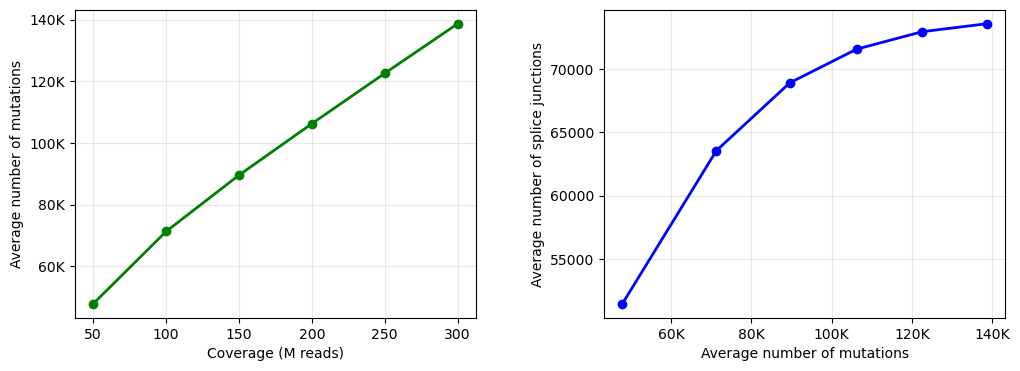

In [4]:
# Label the burden ticks in thousands rather than letting matplotlib park an
# offset next to the axis label.
in_thousands = plt.FuncFormatter(lambda v, _: f"{v / 1e3:.0f}K")

figure, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
figure.subplots_adjust(wspace=0.32)

left.plot(depths, average_burden, marker="o", color="green", linewidth=2, markersize=6)
left.set_xlabel("Coverage (M reads)")
left.set_ylabel(BURDEN_LABEL)
left.set_xticks(depths)
left.yaxis.set_major_formatter(in_thousands)
left.grid(alpha=0.3)

right.plot(average_burden, junctions, marker="o", color="blue",
           linewidth=2, markersize=6)
right.set_xlabel(BURDEN_LABEL)
right.set_ylabel("Average number of splice junctions")
right.xaxis.set_major_formatter(in_thousands)
right.grid(alpha=0.3)

figure.savefig(RESULTS / "Figure_S8.png", dpi=600, bbox_inches="tight")
figure.savefig(RESULTS / "Figure_S8.svg", bbox_inches="tight")
plt.show()